# Section 2: Inference of empirical linguistic state fields

Companion notebook for Section 2 of **"Statistical physics of language change inferred from time evolving maps"** (Burridge & Vaux).

**Goal:** infer the time-evolving spatial distribution of linguistic variants from COSWE survey data using Bayesian Gaussian Process regression with a softmax-linked latent field.

**Inputs:**
- `data/demed_variants/` — per-respondent variant data aggregated to 4,000 Voronoi cells  
- `data/voronois/Voronoi_4000_raw_kmeans_demes.gpkg` — cell geometries, centroids, populations

**Output:** probability field array of shape `(N_cells, N_years, K_variants)` per linguistic variable

**Pre-computed results** for all six paper variables are stored in `data/probability_fields/` (v_4 files).
Running the cross-validation from scratch takes ~30 min per variable. To reproduce exactly, set `N_TRIALS = 30`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import pandas as pd
import geopandas as gpd
from scipy.spatial import distance_matrix
from sklearn.model_selection import train_test_split
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import GP_fitting as gp

In [2]:
# Paths — notebook lives in code/empirical_field_inference/
repo_root   = Path().resolve().parents[1]
voronoi_dir = repo_root / 'data' / 'voronois'
variant_dir = repo_root / 'data' / 'demed_variants'
p_field_dir = repo_root / 'data' / 'probability_fields'

cmap       = 'RdYlBu_r'
n_demes    = 4000
start_year = 1950
end_year   = 2000

N_TRIALS = 10   # published hyperparameters obtained from 30 trials

## §2(a)–(b): Survey data and spatial discretisation

The COSWE survey contains ~10⁵ responses, each with a birth year and approximate childhood location. Using the **apparent-time principle**, birth year serves as a proxy for the historical language state at that time.

Mainland USA is discretised into **N = 4,000 Voronoi cells** seeded from k-means clusters of ZIP code centroids, weighted by 2020 Census population. The mean cell population is ~82,000.

In [3]:
# Load Voronoi tessellation
gdf_voronoi = gpd.read_file(voronoi_dir / f'Voronoi_{n_demes}_raw_kmeans_demes.gpkg')

# Pairwise cell distances in km
DX   = np.column_stack([gdf_voronoi.x.values, gdf_voronoi.y.values])
dmat = distance_matrix(DX, DX) / 1e3

pops = gdf_voronoi['pop'].values

# Standardised log population density z_i (Supplement §1.1)
areas   = gdf_voronoi.geometry.area.values * 1e-6   # km²
log_rho = np.log(pops / areas)
zts     = (log_rho - log_rho.mean()) / log_rho.std()

print(f'N cells:                  {len(gdf_voronoi)}')
print(f'Mean population per cell: {pops.mean():.0f}')
print(f'10th / 90th pctile pop:   {np.quantile(pops, 0.1):.0f} / {np.quantile(pops, 0.9):.0f}')

N cells:                  4000
Mean population per cell: 82302
10th / 90th pctile pop:   11917 / 206571


In [4]:
# Load one linguistic variable: tennis shoes / sneakers (Q3)
csv_file = 'Q2_soda_pop_coke_4000_cells.csv'
df = pd.read_csv(variant_dir / csv_file)

# Variant columns are everything except deme_id and year
variant_cols = [c for c in df.columns if c not in ('deme_id', 'year')]
K = len(variant_cols)

print(f'File:        {csv_file}')
print(f'Variants:    {variant_cols}  (K = {K})')
print(f'Rows (deme/year pairs): {len(df)}, years {df.year.min()}–{df.year.max()}')
df.head()

File:        Q2_soda_pop_coke_4000_cells.csv
Variants:    ['soda', 'pop', 'coke']  (K = 3)
Rows (deme/year pairs): 38172, years 1903–2012


,deme_id,year,soda,pop,coke
0,0,1935,1,0,0
1,0,1940,2,0,0
2,0,1941,2,0,0
3,0,1943,2,0,0
4,0,1944,1,1,0


In [5]:
def make_Y(df, n_demes, start_year, end_year):
    """Build count tensor Y[cell, year-offset, variant] from aggregated CSV data."""
    vcols = [c for c in df.columns if c not in ('deme_id', 'year')]
    T = end_year - start_year + 1
    Y = np.zeros((n_demes, T, len(vcols)), dtype=int)
    sub = df[(df['year'] >= start_year) & (df['year'] <= end_year)].copy()
    ii = sub['deme_id'].astype(int).values
    tt = (sub['year'] - start_year).astype(int).values
    Y[ii, tt] = sub[vcols].values.astype(int)
    return vcols, Y

variant_cols, Y = make_Y(df, n_demes, start_year, end_year)
print(f'Y shape: {Y.shape}  (cells × years × variants)')
print(f'Total respondents: {Y.sum()}')

Y shape: (4000, 51, 3)  (cells × years × variants)
Total respondents: 52940


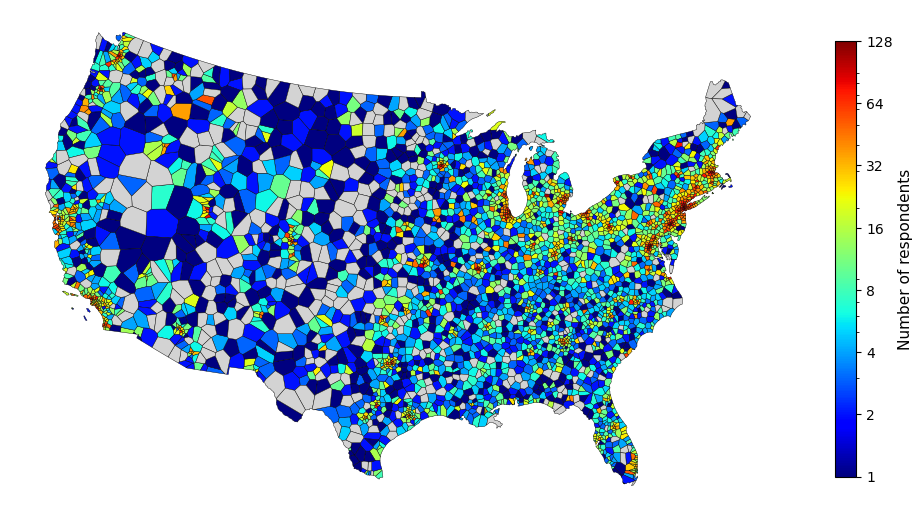

In [6]:
# Respondent density map
data_counts = Y.sum(axis=(1, 2)).astype(float)
data_counts[data_counts == 0] = np.nan

mycmap = plt.get_cmap('jet').copy()
mycmap.set_bad('lightgrey')
norm = mcolors.LogNorm(vmin=1, vmax=128)

fig, ax = plt.subplots(figsize=(10, 7))
mappable = gdf_voronoi.plot(
    column=data_counts, cmap=mycmap, norm=norm,
    linewidth=0.3, edgecolor='k', ax=ax,
    missing_kwds={'color': 'lightgrey'}
)
ax.set_axis_off()

ticks = 2.0 ** np.arange(0, 8)
cbar = fig.colorbar(mappable.collections[0], ax=ax, shrink=0.65)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}'))
cbar.set_label('Number of respondents', fontsize=11)
plt.tight_layout()
plt.show()

## §2(c): Bayesian inference of empirical state fields

We model the state field via a softmax-linked **latent field** $F(\mathbf{r}, t) \in \mathbb{R}^K$:
$$x_{ik}(t) = \text{softmax}(F(\mathbf{r}_i, t))_k = \frac{e^{F_{ik}(t)}}{\sum_j e^{F_{ij}(t)}}$$

The latent field has a separable Gaussian process prior with a **temporal RBF kernel**
$$K_t(t_1, t_2) = \kappa^2 \exp\!\left(-\frac{(t_1-t_2)^2}{\tau^2}\right)$$
and a **non-stationary (Paciorek) spatial kernel** that shrinks the correlation length scale in densely populated areas:
$$\ell_i = \sigma\, e^{-\alpha z_i}, \qquad
K_s(\mathbf{r}_1, \mathbf{r}_2) = \frac{2\ell_1 \ell_2}{\ell_1^2+\ell_2^2}\exp\!\left(-\frac{\|\mathbf{r}_1-\mathbf{r}_2\|^2}{\ell_1^2+\ell_2^2}\right)$$

The four hyperparameters $\psi = (\tau, \sigma, \alpha, \kappa)$ are selected by 80–20 cross-validation, maximising log $p(Y^\text{test} | \hat{F}^\text{train})$.

In [7]:
# GP kernels — see Supplement §1.1

def kernel_time(ts, tau, jitter=1e-8):
    """RBF kernel in time. Multiply by kappa to set variance kappa^2."""
    dt = ts[:, None] - ts[None, :]
    C  = np.exp(-(dt / tau) ** 2)
    C[np.diag_indices_from(C)] += jitter
    return C

def kernel_space(dmat, zts, sigma, alpha, jitter=1e-8):
    """Paciorek kernel with density-dependent length scale ell_i = sigma * exp(-alpha * z_i)."""
    ell  = sigma * np.exp(-alpha * zts)
    ell2 = ell ** 2
    denom     = ell2[:, None] + ell2[None, :]
    prefactor = 2.0 * ell[:, None] * ell[None, :] / denom
    K = prefactor * np.exp(-dmat ** 2 / denom)
    K[np.diag_indices_from(K)] += jitter
    return K

In [8]:
# 80-20 train/test split of (deme, year) rows
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
_, Y_train = make_Y(df_train, n_demes, start_year, end_year)
_, Y_test  = make_Y(df_test,  n_demes, start_year, end_year)

ts = np.arange(end_year - start_year + 1)

def cross_val_bce(tau, sigma, alpha, kappa):
    """Fit MAP field on training data, return log-likelihood on test data."""
    Ks = kappa * kernel_space(dmat, zts, sigma, alpha)
    Kt = kappa * kernel_time(ts, tau)
    Ls = np.linalg.cholesky(Ks)
    Lt = np.linalg.cholesky(Kt)
    _, _, _, P = gp.fit_multinomial_map(Ls, Lt, Y_train)
    return float(np.sum(Y_test * np.log(P + 1e-8)))

def optuna_objective(trial):
    return cross_val_bce(
        tau   = trial.suggest_float('tau',   20,   50),
        sigma = trial.suggest_float('sigma', 300,  500),
        alpha = trial.suggest_float('alpha', 0.0,  0.5),
        kappa = trial.suggest_float('kappa', 0.75, 1.25),
    )

print(f'Running Optuna hyperparameter search ({N_TRIALS} trials) ...')
study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print(f'\nBest hyperparameters:')
for k, v in best.items():
    print(f'  {k} = {v:.2f}')

Running Optuna hyperparameter search (10 trials) ...


  0%|          | 0/10 [00:00<?, ?it/s]


Best hyperparameters:
  tau = 33.00
  sigma = 423.13
  alpha = 0.35
  kappa = 1.01


In [ ]:
# MAP estimation on the full dataset using selected hyperparameters
_, Y_full = make_Y(df, n_demes, start_year, end_year)

Ks = best['kappa'] * kernel_space(dmat, zts, best['sigma'], best['alpha'])
Kt = best['kappa'] * kernel_time(ts, best['tau'])
Ls = np.linalg.cholesky(Ks)
Lt = np.linalg.cholesky(Kt)

_, _, _, P = gp.fit_multinomial_map(Ls, Lt, Y_full)
print(f'P shape: {P.shape}  (cells × years × variants)')

P shape: (4000, 51, 3)  (cells × years × variants)


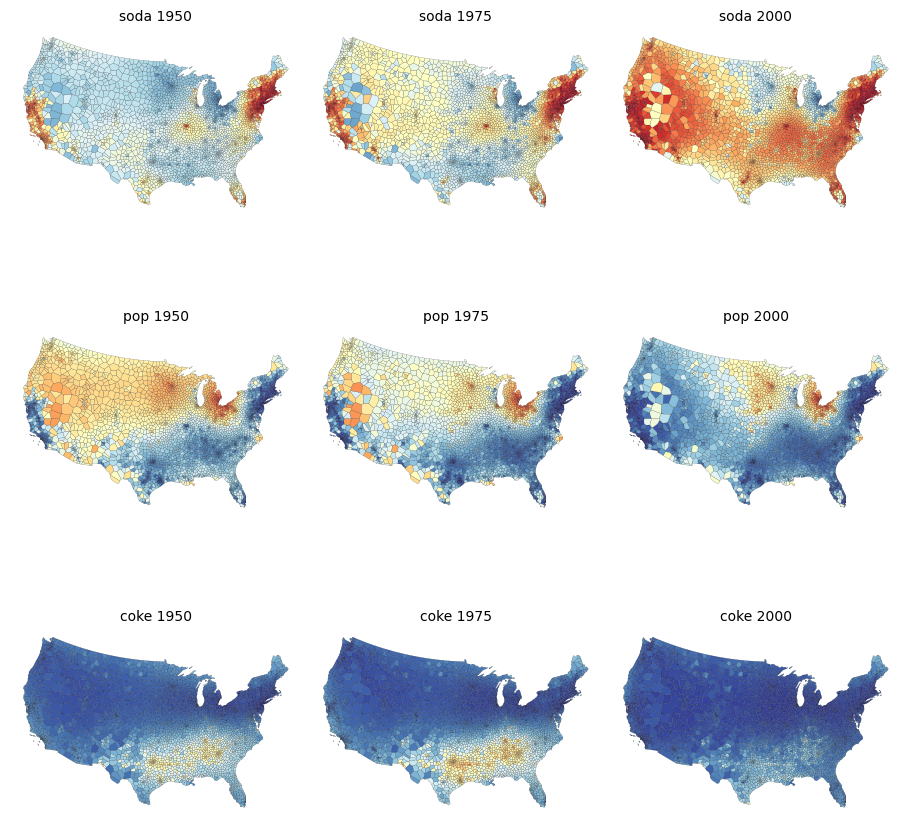

In [ ]:
# Plot inferred state fields at three time slices
plot_years = [1950, 1975, 2000]

fig, axs = plt.subplots(K, len(plot_years), figsize=(9, 3 * K), constrained_layout=True)
if K == 1:
    axs = axs[None, :]  # ensure 2D indexing

for j, yr in enumerate(plot_years):
    t = yr - start_year
    for k in range(K):
        gdf_voronoi.plot(
            column=P[:, t, k], ax=axs[k, j],
            cmap=cmap, vmin=0, vmax=1,
            linewidth=0.1, edgecolor='k'
        )
        axs[k, j].set_axis_off()
        axs[k, j].set_title(f'{variant_cols[k]} {yr}', fontsize=10)

plt.show()

## Pre-computed fields for all six variables

The `data/probability_fields/` directory contains MAP fields for all six paper variables, computed with N_TRIALS = 30 and hyperparameter bounds as described in Supplement §1.2.
Files are named `v_4_{variants}_{n_demes}_demes_tau_{tau}_sigma_{sigma}_alpha_{alpha}_var_{kappa}_start_1950_end_2000.npy`.

In [ ]:
v4_files = sorted(glob.glob(str(p_field_dir / 'v_4_*.npy')))

print(f'Found {len(v4_files)} pre-computed v4 probability fields:')
for f in v4_files:
    P = np.load(f)
    stem = Path(f).stem
    K_v  = P.shape[2]
    parts = stem.split('_')
    var_str = ' / '.join(parts[2:2 + K_v])
    print(f'  {var_str:40s}  shape {P.shape}')

Found 6 pre-computed v4 probability fields:
  crawfish / crayfish / crawdad             shape (4000, 51, 3)
  roly / bug                                shape (4000, 51, 2)
  soda / pop / coke                         shape (4000, 51, 3)
  sunshower / devil                         shape (4000, 51, 2)
  tennis / sneakers                         shape (4000, 51, 2)
  you-guys / you-all                        shape (4000, 51, 2)


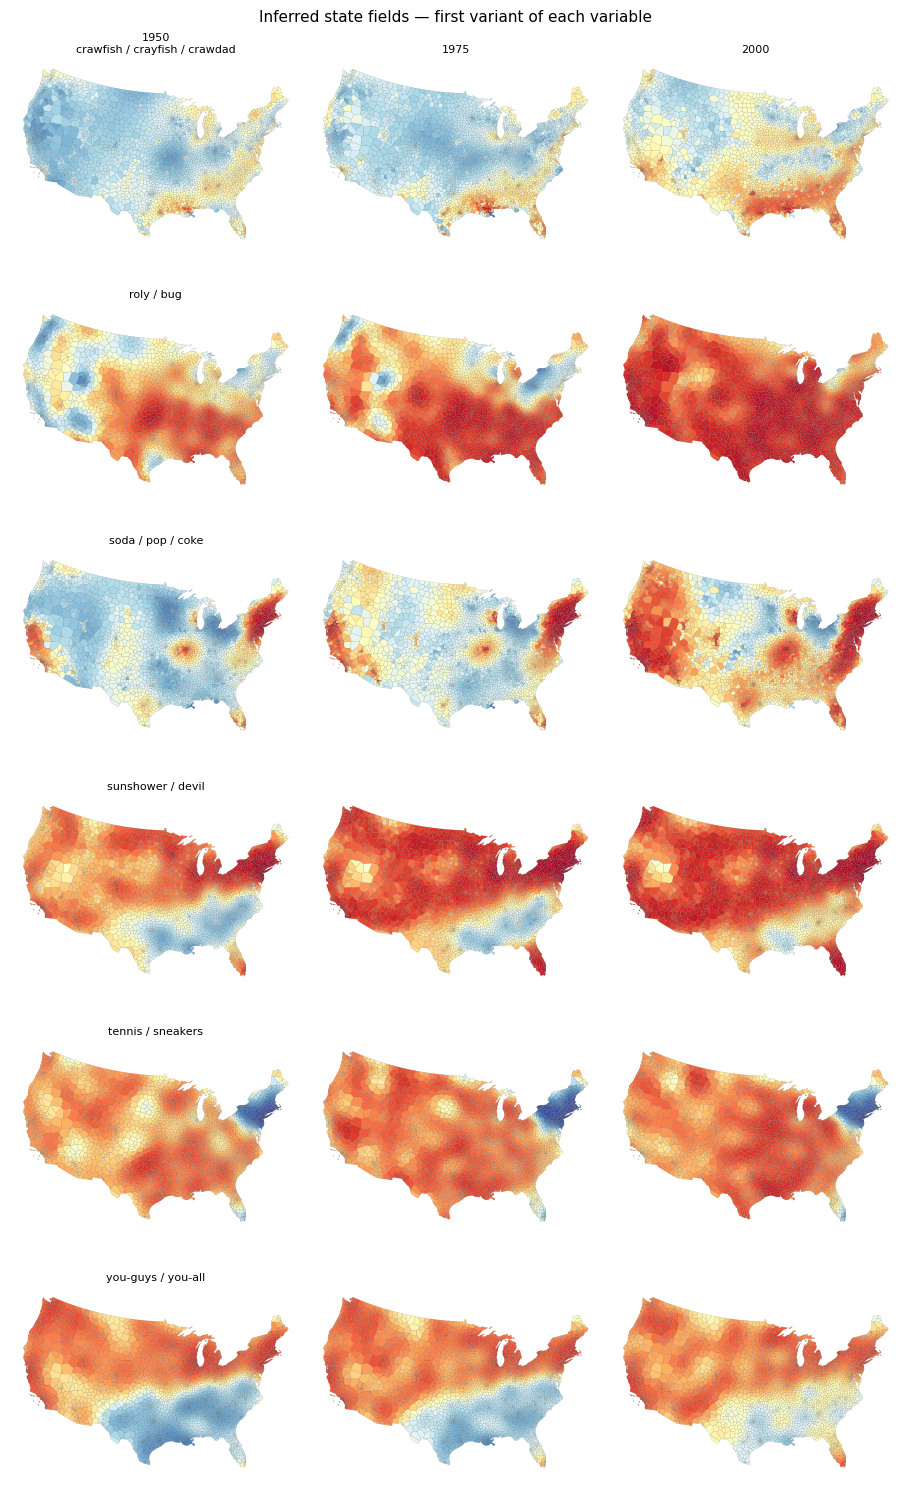

In [ ]:
# Plot first variant of each variable at 1950, 1975, 2000
plot_years = [1950, 1975, 2000]
n_vars = len(v4_files)

fig, axs = plt.subplots(n_vars, len(plot_years),
                        figsize=(9, 2.5 * n_vars), constrained_layout=True)

for row, f in enumerate(v4_files):
    P_v   = np.load(f)
    K_v   = P_v.shape[2]
    parts = Path(f).stem.split('_')
    label = ' / '.join(parts[2:2 + K_v])

    for col, yr in enumerate(plot_years):
        t  = yr - start_year
        ax = axs[row, col]
        gdf_voronoi.plot(
            column=P_v[:, t, 0], ax=ax,
            cmap=cmap, vmin=0, vmax=1,
            linewidth=0.05, edgecolor='k'
        )
        ax.set_axis_off()
        title_parts = []
        if row == 0:
            title_parts.append(str(yr))
        if col == 0:
            title_parts.append(label)
        if title_parts:
            ax.set_title('\n'.join(title_parts), fontsize=8)

plt.suptitle('Inferred state fields — first variant of each variable', fontsize=11)
plt.show()